# How Inference Happens — one document, end-to-end (detailed)

**Dissertation:** *SLM vs LLM for Key Information Extraction from financial documents.*

This notebook is the **maximally verbose** walkthrough: it takes **one real document**
and prints **every intermediate** as it flows through the exact production pipeline
(`src/`) — OCR record → simple JSON → prompt → constrained schema → model call → parse →
score → efficiency — then scales to the frozen 20-document SLM-vs-LLM comparison and the
Phase-3 fine-tuned before→after.

It runs **offline from saved results** (`results/runs.jsonl`) so *Run All* never fails;
live Ollama / fine-tuned cells are optional and skip gracefully.

## 0 · Setup

In [1]:
import sys, json, textwrap
from pathlib import Path

def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'config' / 'config.yaml').exists():
            return p
    raise RuntimeError('repo root not found')

ROOT = _find_root(Path.cwd()); sys.path.insert(0, str(ROOT))
import pandas as pd

from src.config import load_config, resolve_path
from src.data.gt import align_gold, load_test_records, load_test_set, schema_for_record
from src.data.preprocess import from_dataset_record
from src.prompts.builder import build_prompt, json_schema_format
from src.eval.parse import parse_prediction
from src.eval.metrics import score_document
from src.runner.results_store import load_rows

cfg = load_config()
rows = load_rows(resolve_path(cfg, cfg['paths']['runs_jsonl']))
print(f'loaded {len(rows)} result rows from runs.jsonl')
SHOT, VARIANT = 'zero_shot', 'lines_plus_kv'   # the condition we trace

loaded 880 result rows from runs.jsonl


## Stage 0 · Pick one document

A clean SROIE receipt — easy to read on a projector. The *identical* code runs on a
complex Kleister charity report; only the schema differs.

In [2]:
records = load_test_records(cfg)
record = next((r for r in records if r.get('schema_name') == 'sroie'), records[0])
schema = schema_for_record(cfg, record)
gold = align_gold(record.get('gold', {}), schema)
print('doc_id:', record['doc_id'], '| dataset:', record['dataset'])
print('gold fields:'); print(json.dumps(gold, indent=2, ensure_ascii=False))

doc_id: 132 | dataset: sroie
gold fields:
{
  "company": "FARMASI MALURI S/B",
  "date": "02/03/18",
  "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.",
  "total": "79.35"
}


## Stage 1 · OCR record → *simple JSON*

`from_dataset_record()` normalises the raw OCR (SROIE ships word boxes; Kleister ships
lines) into one uniform shape: `lines`, `key_values`, `tables`. Everything downstream is
source-agnostic because of this single canonical form.

In [3]:
simple = from_dataset_record(record)
print('LINES ({} total):'.format(len(simple['lines'])))
for ln in simple['lines'][:25]:
    print('   ', ln)
if len(simple['lines']) > 25: print('    …')
print('\nKEY_VALUES:', json.dumps(simple['key_values'], ensure_ascii=False)[:300])
print('TABLES:', len(simple['tables']), 'table(s)')

LINES (28 total):
    3180301
    FARMASI MALURI S/B (587969-U)
    GST NO: 000342237184 (ID:5033)
    23, JIN BURUNG JENTAYU, TMN BUKIT
    MALURI, KEPONG, 52100 KL.
    TAX INVOICE
    CASHIER : POS1N M/C. ID :POS7
    RECEIPT : 71857936 02/03/18 05:16 PM
    DESCRIPTION DISC. SUBTOTAL
    061558 - **BMS MILK THISTLE
    1 X 111.30 36.75 72.35 S
    910845 - TRILON-E CRM
    1 X 7.00 7.00 Z
    TOTAL (INCLUDING GST) 79.35
    ROUNDING 0.00
    NET 79.35
    TENOER 100.00
    CHANGE/BALANCE 20.65
    GST SUMMARY AMT (EXCL. GST) TAX (RM)
    ZRL @0.00% 7.00 0.00
    SR @ 6.00% 68.25 4.10
    GOODS SOLD ARE NON-REFUNDABLE BUT
    EXCHANGEABLE WITHIN 7 DAYS WITH
    RECEIPT PLUS GOODS ARE IN
    RESALEABLE CONDITION.
    …

KEY_VALUES: {}
TABLES: 0 table(s)


## Stage 2 · Build the prompt

`build_prompt()` assembles the **instruction** (with the exact field list) and the
**document block**. Below is the *entire* prompt string sent to the model — nothing is
hidden.

In [4]:
prompt = build_prompt(schema, simple, SHOT, VARIANT, None,
                      max_lines=cfg['conditions'].get('max_input_lines'))
print(prompt)

You are a precise information-extraction system for financial documents.

You are given the text of a document (its lines, and optionally detected
key/value pairs). Extract the following fields and return them as a single JSON
object with EXACTLY these keys:

- "company" (string, required)
- "date" (date, required)
- "address" (string, required)
- "total" (currency, required)

Rules:
- Return ONLY the JSON object. No explanation, no markdown, no code fences.
- Use the exact key names listed above.
- If a field cannot be found in the document, set its value to null.
- Copy values verbatim from the document where possible; do not invent data.


### Document
LINES:
3180301
FARMASI MALURI S/B (587969-U)
GST NO: 000342237184 (ID:5033)
23, JIN BURUNG JENTAYU, TMN BUKIT
MALURI, KEPONG, 52100 KL.
TAX INVOICE
CASHIER : POS1N M/C. ID :POS7
RECEIPT : 71857936 02/03/18 05:16 PM
DESCRIPTION DISC. SUBTOTAL
061558 - **BMS MILK THISTLE
1 X 111.30 36.75 72.35 S
910845 - TRILON-E CRM
1 X 7.00 7.00 Z
TOT

### Constrained decoding (local models)

For **local** models the runner also passes this JSON schema to Ollama's `format`, which
*forces* syntactically valid JSON with exactly the required keys — this alone eliminated
most small-model parse failures (FINDINGS `[E2]`).

In [5]:
print(json.dumps(json_schema_format(schema), indent=2))

{
  "type": "object",
  "properties": {
    "company": {
      "type": "string"
    },
    "date": {
      "type": "string"
    },
    "address": {
      "type": "string"
    },
    "total": {
      "type": "string"
    }
  },
  "required": [
    "company",
    "date",
    "address",
    "total"
  ]
}


## Stage 3 · The model call

The runner turns `prompt → RunResult(text, latency_s, tokens, peak_mem_mb)`. For a
deterministic demo we **replay** what a real model actually returned on this document
(from `runs.jsonl`). An optional live Ollama cell follows.

In [6]:
doc_rows = [r for r in rows if r['doc_id'] == record['doc_id']]
avail = sorted({r['model_id'] for r in doc_rows})
print('models with saved rows for this doc:', avail)
DEMO_MODEL = next((m for m in ['gemma3-4b', 'phi4-mini', 'gemma2-2b'] if m in avail), avail[0])

def pick_row(model_id):
    exact = [r for r in doc_rows if r['model_id'] == model_id
             and r['shot_mode'] == SHOT and r['input_variant'] == VARIANT]
    return (exact or [r for r in doc_rows if r['model_id'] == model_id])[0]

row = pick_row(DEMO_MODEL)
pred_replay = row.get('predicted_json')
print(f"\n[replay] {DEMO_MODEL}  shot={row['shot_mode']}  input={row['input_variant']}")
print('predicted JSON:'); print(json.dumps(pred_replay, indent=2, ensure_ascii=False))

models with saved rows for this doc: ['frontier-llm', 'gemma2-2b', 'gemma3-1b', 'gemma3-4b', 'gemma4-31b', 'large-open-llm', 'llama3.2-1b', 'mistral-7b', 'phi4-mini', 'qwen2.5-0.5b', 'smollm2-360m']

[replay] gemma3-4b  shot=zero_shot  input=lines_plus_kv
predicted JSON:
{
  "company": "FARMASI MALURI S/B",
  "date": "02/03/18",
  "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.",
  "total": "79.35"
}


*(Optional)* a **live** on-device call via Ollama — runs only if Ollama is up and the
model is pulled; otherwise it skips and the replay result above stands.

In [7]:
try:
    from src.models.ollama_runner import OllamaRunner
    runner = OllamaRunner(model_id=DEMO_MODEL,
                          tag=next(m['tag'] for m in cfg['models'] if m['id'] == DEMO_MODEL),
                          ollama_cfg=cfg['ollama'])
    runner.ensure_available()
    res = runner.run(prompt, json_schema_format(schema))
    print('LIVE raw output:\n', res.text)
    print(f'\nlatency={res.latency_s}s  peak_mem={res.peak_mem_mb}MB')
except Exception as e:
    print(f'[live skipped] {type(e).__name__}: {e}')
    print('Using the replayed result — the rest of the notebook is unaffected.')

[live skipped] RuntimeError: Ollama not reachable at http://localhost:11434. Start it with `ollama serve`. (HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/tags (Caused by NewConnectionError("HTTPConnection(host='localhost', port=11434): Failed to establish a new connection: [Errno 61] Connection refused")))
Using the replayed result — the rest of the notebook is unaffected.


## Stage 4 · Parse — robust JSON extraction

Models don't always emit clean JSON: fences, a sentence of preamble, trailing chatter.
`parse_prediction()` strips all that, extracts the first JSON object, validates against
the schema, and — critically — returns a structured error instead of raising, so one bad
output can't crash an 880-cell run.

In [8]:
messy = ('Sure! Here is the extracted information:\n```json\n'
         + json.dumps(pred_replay, ensure_ascii=False)
         + '\n```\nHope this helps!')
print('RAW (messy) model text:\n', messy)
pred, err = parse_prediction(messy, schema)
print('\nPARSED dict:', json.dumps(pred, ensure_ascii=False))
print('parse_error:', err)

RAW (messy) model text:
 Sure! Here is the extracted information:
```json
{"company": "FARMASI MALURI S/B", "date": "02/03/18", "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.", "total": "79.35"}
```
Hope this helps!



PARSED dict: {"company": "FARMASI MALURI S/B", "date": "02/03/18", "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.", "total": "79.35"}
parse_error: None


## Stage 5 · Score — field-level, type-aware

`score_document()` classifies **each field** into one of five categories, then computes
micro precision / recall / F1. Matching is type-aware (a date matches regardless of
surface format).

In [9]:
score = score_document(gold, pred, schema)
table = []
for f in [x['name'] for x in schema['fields']]:
    table.append({'field': f,
                  'gold': gold.get(f), 'predicted': (pred or {}).get(f),
                  'status': score['per_field'][f]})
display(pd.DataFrame(table))
print(f"precision={score['precision']:.2f}  recall={score['recall']:.2f}  "
      f"F1={score['f1']:.2f}  exact_doc={score['exact_match_doc']}  "
      f"({score['exact_match_fields']}/{score['n_fields']} fields exact)")
print('counts:', score['counts'])

,field,gold,predicted,status
0,company,FARMASI MALURI S/B,FARMASI MALURI S/B,tp
1,date,02/03/18,02/03/18,tp
2,address,"23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPO...","23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPO...",tp
3,total,79.35,79.35,tp


precision=1.00  recall=1.00  F1=1.00  exact_doc=True  (4/4 fields exact)
counts: {'tp': 4, 'wrong': 0, 'missing': 0, 'hallucinated': 0, 'tn': 0}


## Stage 6 · Efficiency — the other half of the story

Accuracy alone doesn't answer the research question; **cost and speed** do. These are the
real per-call figures recorded for this model on this document.

In [10]:
eff = {k: row.get(k) for k in
       ('latency_s', 'tokens_per_s', 'peak_mem_mb', 'prompt_tokens', 'completion_tokens', 'cost_usd')}
eff['is_local'] = row.get('is_local')
display(pd.DataFrame([eff], index=[DEMO_MODEL]))

,latency_s,tokens_per_s,peak_mem_mb,prompt_tokens,completion_tokens,cost_usd,is_local
gemma3-4b,4.933,16.83,1159.8,553,83,0.0,True


## Stage 7 · The whole pipeline as one loop → the standings

Stages 1–6 are exactly what `run.py` repeats over documents × models × conditions to
produce `runs.jsonl`. Aggregated, that is the SLM-vs-LLM answer: F1 against model size,
with latency, memory, and cost per document.

In [11]:
from src.analysis.aggregate import load_results_df, per_model
df = load_results_df(cfg)
pm = per_model(df, cfg)
cols = ['display_name', 'params_b', 'f1_macro', 'recall', 'exact_match_rate',
        'latency_s', 'peak_mem_mb', 'cost_mid_per_doc']
display(pm[cols].reset_index(drop=True))

,display_name,params_b,f1_macro,recall,exact_match_rate,latency_s,peak_mem_mb,cost_mid_per_doc
0,SmolLM2-360M,0.36,0.3062,0.2625,0.0000,3.604,1161.5,0.000062
1,Qwen2.5-0.5B,0.50,0.3810,0.3354,0.0000,3.564,1467.7,0.000057
2,Llama-3.2-1B,1.00,0.2771,0.2521,0.0000,6.149,1888.8,0.000110
3,Gemma-3-1B,1.00,0.4171,0.3604,0.0125,4.013,1615.8,0.000066
4,Gemma-2-2B,2.00,0.6113,0.5417,0.1125,11.315,2411.8,0.000083
5,Phi-4-mini,3.80,0.5279,0.4375,0.1250,9.059,3221.7,0.000122
6,Gemma-3-4B,4.00,0.6394,0.5917,0.0875,13.765,1510.2,0.000140
7,Mistral-7B,7.00,0.6415,0.5708,0.1000,28.315,4780.8,0.000205
8,Gemma-4-31B,31.00,0.7005,0.6208,0.1875,2.533,NaN,0.000537
9,Llama-3.3-70B,70.00,0.6666,0.6083,0.1250,16.062,NaN,0.001054


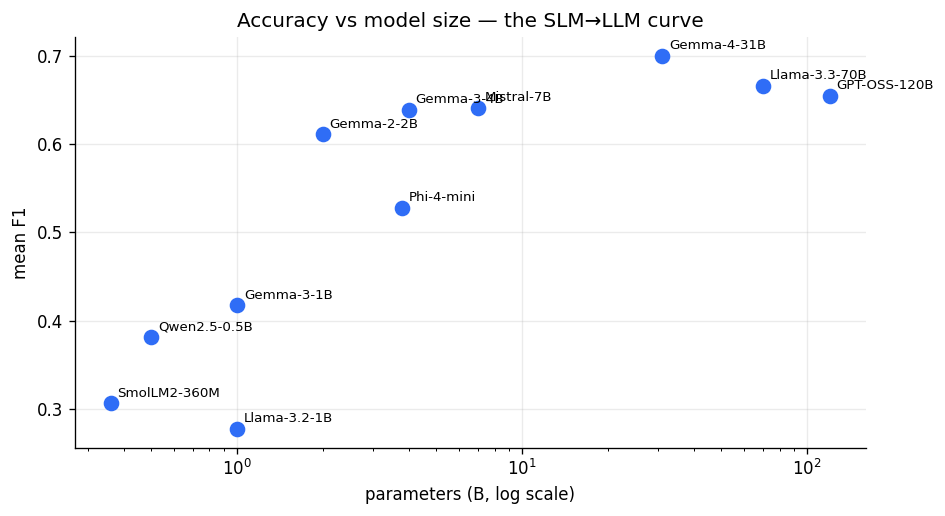

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25})
p = pm.dropna(subset=['params_b'])
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.scatter(p['params_b'], p['f1_macro'], s=70, color='#2f6df6', zorder=3)
for _, r in p.iterrows():
    ax.annotate(r['display_name'], (r['params_b'], r['f1_macro']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xscale('log'); ax.set_xlabel('parameters (B, log scale)'); ax.set_ylabel('mean F1')
ax.set_title('Accuracy vs model size — the SLM→LLM curve'); plt.tight_layout(); plt.show()

## Stage 8 · Phase-3 — fine-tuned before → after

The dissertation headline: does task-tuning a small model close the gap? This compares
**`phi4-mini`** with its QLoRA fine-tune **`phi4-mini-ft`** on the *same* documents. It
renders as soon as `phi4-mini-ft` rows exist in `runs.jsonl` (see `docs/QLORA.md`);
until then it prints the baseline and how to produce the fine-tune.

In [13]:
have_ft = (df['model_id'] == 'phi4-mini-ft').any()
if have_ft:
    pair = pm[pm['model_id'].isin(['phi4-mini', 'phi4-mini-ft'])][
        ['display_name', 'f1_macro', 'recall', 'exact_match_rate', 'latency_s', 'cost_mid_per_doc']]
    display(pair.reset_index(drop=True))
    base = pm[pm['model_id'] == 'phi4-mini']['f1_macro'].iloc[0]
    ft = pm[pm['model_id'] == 'phi4-mini-ft']['f1_macro'].iloc[0]
    print(f'\nΔF1 (fine-tuned − base) = {ft - base:+.3f}')
else:
    base = pm[pm['model_id'] == 'phi4-mini']
    if len(base):
        print('Baseline phi4-mini F1_macro =', base['f1_macro'].iloc[0])
    print('\nphi4-mini-ft not in runs.jsonl yet. To produce it:')
    print('  1) python scripts/make_train_data.py')
    print('  2) run notebooks/03_qlora_finetune.ipynb on Kaggle -> download GGUF')
    print('  3) bash scripts/import_finetuned.sh artifacts/phi4-mini-ft.Q4_K_M.gguf artifacts/Modelfile')
    print('  4) python scripts/run_eval.py --models phi4-mini-ft   # then re-run this cell')

Baseline phi4-mini F1_macro = 0.5279

phi4-mini-ft not in runs.jsonl yet. To produce it:
  1) python scripts/make_train_data.py
  2) run notebooks/03_qlora_finetune.ipynb on Kaggle -> download GGUF
  3) bash scripts/import_finetuned.sh artifacts/phi4-mini-ft.Q4_K_M.gguf artifacts/Modelfile
  4) python scripts/run_eval.py --models phi4-mini-ft   # then re-run this cell


---
**Recap.** One document, every stage printed: normalise → prompt (+ constrained schema)
→ model → robust parse → type-aware score → efficiency. The same loop over the frozen
20-doc grid produces the standings, and Phase-3 adds the fine-tuned before→after — the
full evidence chain from raw OCR to the dissertation's answer.